Starting test: Finding solutions for the first 24 robots...

--- Test Completed ---
Total Stations Built: 2 | Total Cost: £2252.98


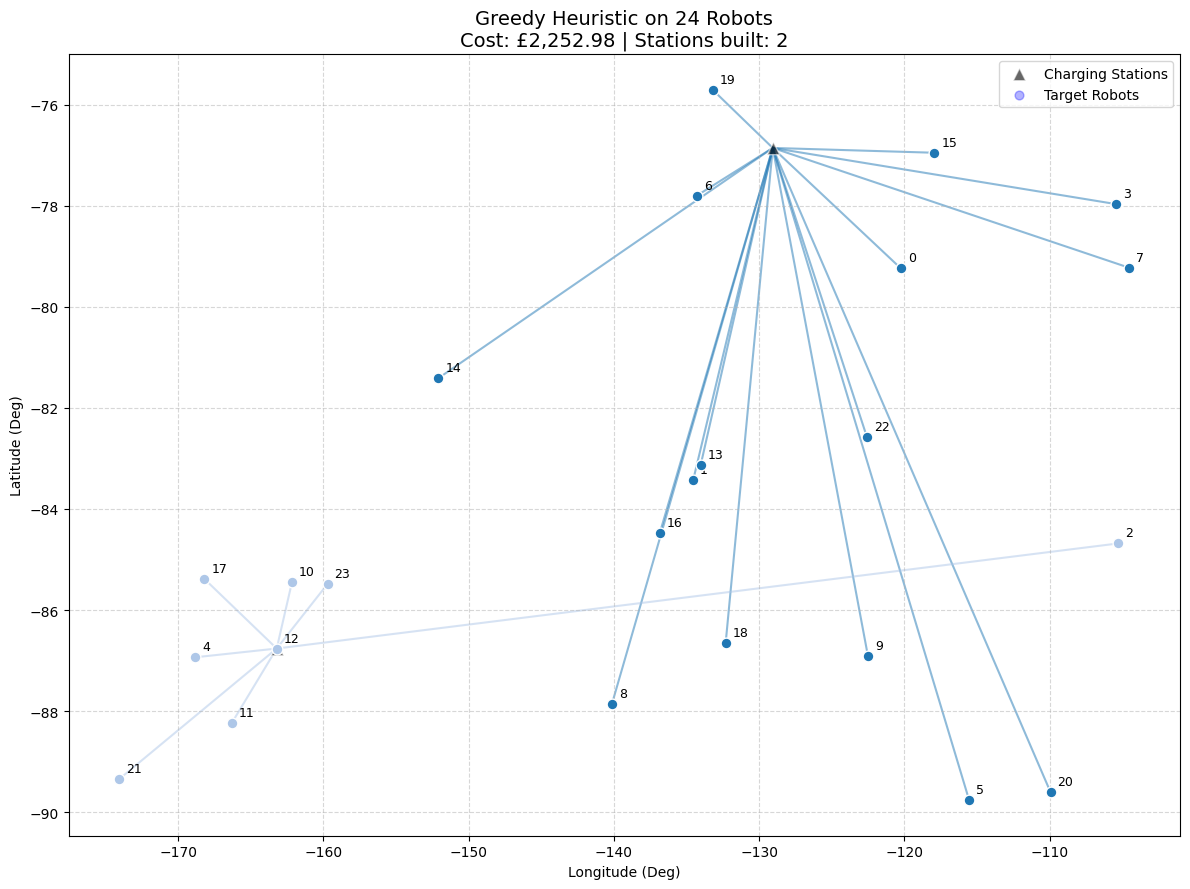


=== Starting LOCAL SEARCH HEURISTIC (Phase 1 -> 2 -> 3) ===

[Initial State] Greedy service cost (excluding penalties): £2252.98 | Stations: 2
[Phase 1 Finished] Executed 2 transfers. Service Cost: £2234.48 | Stations: 2 | Time: 0.00s
[Phase 2 Finished] Executed 0 merges. Service Cost: £2234.48 | Stations: 2 | Time: 0.00s
[Phase 3 Finished] Executed 1 fine-tuning adjustments. Final Service Cost: £2220.57 | Time: 0.00s

================ Final Optimization Results ================
Total Cost before Local Search (Greedy): £2252.98
Total Cost after Local Search (LS):      £2220.57
Total Cost Savings Achieved:             £32.41



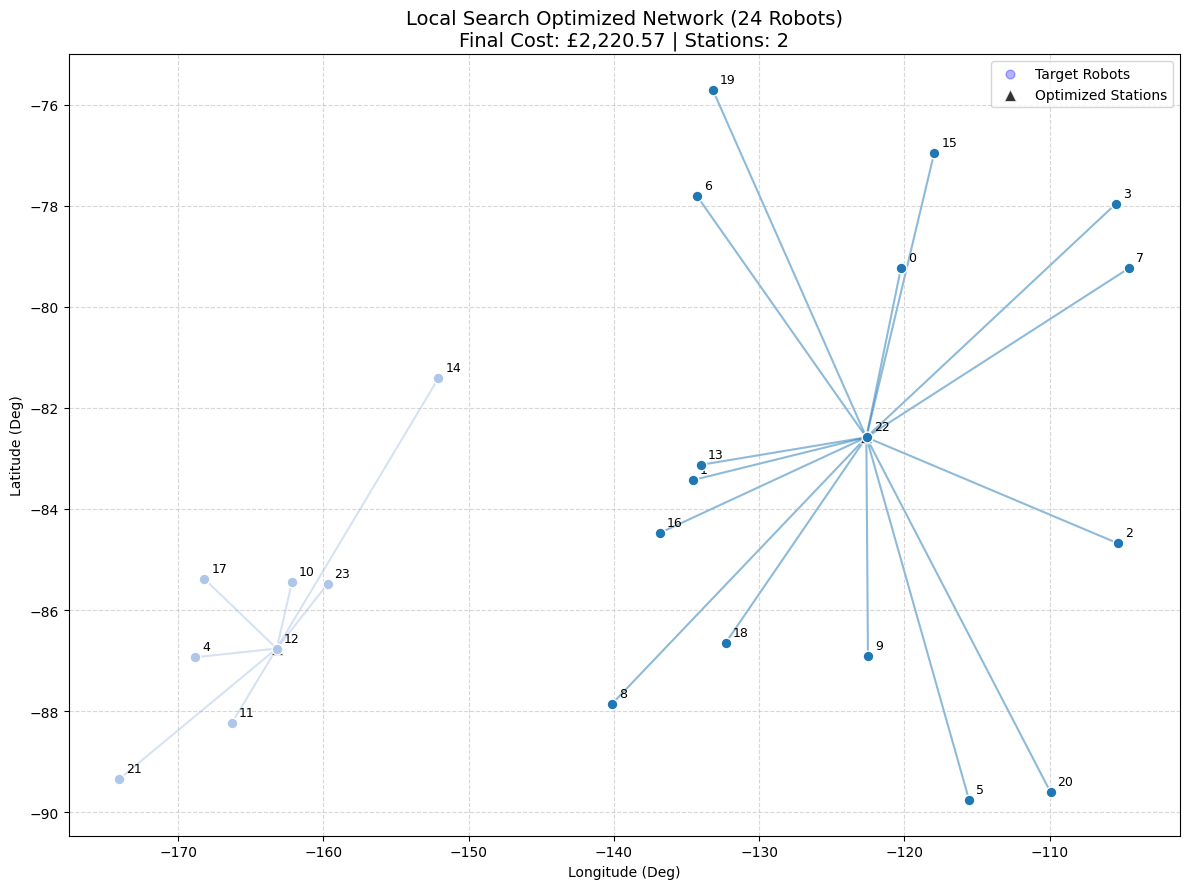

In [1]:
# 24 robots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import time

# =========================================================
# 1. Data Loading and Preprocessing
# =========================================================
df_loc = pd.read_csv('robot_locations.csv')
df_range = pd.read_csv('range.csv')

# Extract coordinates and ranges
coords = df_loc[['longitude', 'latitude']].values
ranges = df_range['range'].values
N = len(coords)

# =========================================================
# 2. Distance Matrix Calculation 
# (Removed 111.111 conversion, using Euclidean distance directly)
# =========================================================
diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

# =========================================================
# 3. Cost Parameters
# =========================================================
C_b = 5000                
C_m = 500                 
C_b_daily = C_b / 365.0   # Daily station construction cost (approx £13.70)
C_m_daily = C_m / 365.0   # Daily maintenance cost (approx £1.37)
C_c = 0.42                
C_h = 1000                
MAX_ROBOTS = 16           
R_MAX = 175 * 1.60934     # ★ r_max (aligned with 1(a) value 281.63)

# =========================================================
# 4. Greedy Heuristic (Testing on the first 24 robots)
# =========================================================
SUBSET_SIZE = 24  

unassigned = set(range(SUBSET_SIZE))
candidates = set(range(N))

stations_built = []     
total_cost = 0

print(f"Starting test: Finding solutions for the first {SUBSET_SIZE} robots...")

start_time = time.time()
iteration = 0

while unassigned:
    best_savings = 0
    best_candidate = None
    best_subset = []
    best_cost_serve = 0
    
    for j in candidates:
        reachable = []
        for i in unassigned:
            if dist_matrix[i, j] <= ranges[i]:
                reachable.append(i)
                
        if not reachable: continue
            
        reachable.sort(key=lambda i: dist_matrix[i, j])
        subset = reachable[:MAX_ROBOTS]
        n_served = len(subset)
        
        cost_penalty = n_served * C_h
        chargers_needed = math.ceil(n_served / 2)
        
        # ★ C3: (R_MAX - self_range + flight_distance) * 0.42
        cost_flying = sum((R_MAX - ranges[i] + dist_matrix[i, j]) * C_c for i in subset)
        
        cost_serve = C_b_daily + (chargers_needed * C_m_daily) + cost_flying
        savings = cost_penalty - cost_serve
        
        if savings > best_savings:
            best_savings = savings
            best_candidate = j
            best_subset = subset
            best_cost_serve = cost_serve
            
    if best_savings > 0:
        iteration += 1
        stations_built.append((best_candidate, best_subset))
        total_cost += best_cost_serve
        candidates.remove(best_candidate)
        for robot in best_subset: unassigned.remove(robot)
    else:
        break

unassigned_cost = len(unassigned) * C_h
total_cost += unassigned_cost

print(f"\n--- Test Completed ---")
print(f"Total Stations Built: {len(stations_built)} | Total Cost: £{total_cost:.2f}")

# =========================================================
# 5. Visualization
# =========================================================
fig, ax = plt.subplots(figsize=(12, 9))

# ID Labels
for i in range(SUBSET_SIZE):
    ax.annotate(str(i), (coords[i, 0], coords[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=9)

# Draw red 'x' markers for robots incurring a penalty (unassigned)
unassigned_list = list(unassigned)
if unassigned_list:
    ax.scatter(coords[unassigned_list, 0], coords[unassigned_list, 1], 
               c='red', marker='x', s=100, linewidth=2, label='Unassigned (Penalty)', zorder=3)

station_coords_x, station_coords_y = [], []
cmap = plt.get_cmap('tab20') 

# Draw charging stations and connection lines
for idx, (stat_id, robots) in enumerate(stations_built):
    color = cmap(idx % 20)
    sx, sy = coords[stat_id]
    station_coords_x.append(sx); station_coords_y.append(sy)
    
    for r_id in robots:
        rx, ry = coords[r_id]
        ax.plot([rx, sx], [ry, sy], c=color, alpha=0.5, linewidth=1.5, zorder=1)
        ax.scatter(rx, ry, c=[color], s=60, edgecolors='white', zorder=5)

# Draw charging station icons (triangles)
if station_coords_x:
    ax.scatter(station_coords_x, station_coords_y, c='black', marker='^', s=80, alpha=0.6, edgecolors='white', zorder=4, label='Charging Stations')

# Draw underlying target robots
ax.scatter(coords[:SUBSET_SIZE, 0], coords[:SUBSET_SIZE, 1], c='blue', s=40, alpha=0.3, label='Target Robots', zorder=2)

ax.set_title(f'Greedy Heuristic on {SUBSET_SIZE} Robots\nCost: £{total_cost:,.2f} | Stations built: {len(stations_built)}', fontsize=14)
ax.set_xlabel('Longitude (Deg)'); ax.set_ylabel('Latitude (Deg)')
ax.legend(loc='best'); ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()






# =========================================================
# 6. LOCAL SEARCH HEURISTIC (Phase 1 -> 2 -> 3)
# =========================================================
import copy

print("\n=======================================================")
print("=== Starting LOCAL SEARCH HEURISTIC (Phase 1 -> 2 -> 3) ===")
print("=======================================================\n")

# Helper Function 1: Calculate Euclidean distance between two points
def calc_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# Helper Function 2: Calculate actual total cost for a station (Aligned with Greedy logic)
def calc_station_cost(station_coords, robots_list):
    if not robots_list:
        return 0 # Empty stations incur no cost
    chargers = math.ceil(len(robots_list) / 2)
    c_fly = sum((R_MAX - ranges[r] + calc_dist(coords[r], station_coords)) * C_c for r in robots_list)
    return C_b_daily + chargers * C_m_daily + c_fly

# =========================================================
# Initialize Local Search State
# =========================================================
active_stations = {}
stat_counter = 0
for stat_id, r_list in stations_built:
    active_stations[stat_counter] = {
        'coords': (coords[stat_id][0], coords[stat_id][1]),
        'robots': list(r_list)
    }
    stat_counter += 1

current_ls_cost = sum(calc_station_cost(s['coords'], s['robots']) for s in active_stations.values())
print(f"[Initial State] Greedy service cost (excluding penalties): £{current_ls_cost:.2f} | Stations: {len(active_stations)}")

# =========================================================
# Phase 1: Reassign & Drop (1-Shift)
# =========================================================
start_p1 = time.time()
improvement = True
iter_p1 = 0

while improvement:
    improvement = False
    stat_ids = list(active_stations.keys())
    
    for s_old_id in stat_ids:
        if s_old_id not in active_stations: continue
        
        robots_in_old = list(active_stations[s_old_id]['robots'])
        for robot in robots_in_old:
            best_move_savings = 0.001
            best_s_new_id = None
            
            for s_new_id in stat_ids:
                if s_new_id == s_old_id or s_new_id not in active_stations: continue
                if len(active_stations[s_new_id]['robots']) >= MAX_ROBOTS: continue
                
                new_coords = active_stations[s_new_id]['coords']
                if calc_dist(coords[robot], new_coords) > ranges[robot]: continue
                
                old_cost_A = calc_station_cost(active_stations[s_old_id]['coords'], active_stations[s_old_id]['robots'])
                old_cost_B = calc_station_cost(active_stations[s_new_id]['coords'], active_stations[s_new_id]['robots'])
                
                temp_old_robots = [r for r in active_stations[s_old_id]['robots'] if r != robot]
                temp_new_robots = active_stations[s_new_id]['robots'] + [robot]
                
                new_cost_A = calc_station_cost(active_stations[s_old_id]['coords'], temp_old_robots)
                new_cost_B = calc_station_cost(active_stations[s_new_id]['coords'], temp_new_robots)
                
                savings = (old_cost_A + old_cost_B) - (new_cost_A + new_cost_B)
                
                if savings > best_move_savings:
                    best_move_savings = savings
                    best_s_new_id = s_new_id
            
            if best_s_new_id is not None:
                active_stations[s_old_id]['robots'].remove(robot)
                active_stations[best_s_new_id]['robots'].append(robot)
                current_ls_cost -= best_move_savings
                improvement = True
                iter_p1 += 1
                
        if len(active_stations[s_old_id]['robots']) == 0:
            del active_stations[s_old_id]

print(
    f"[Phase 1 Finished] Executed {iter_p1} transfers. "
    f"Service Cost: £{current_ls_cost:.2f} | "
    f"Stations: {len(active_stations)} | "
    f"Time: {time.time()-start_p1:.2f}s"
)

# =========================================================
# Phase 2: Merge & Shift (k-to-1 continuous drift)
# =========================================================
start_p2 = time.time()
improvement = True
iter_p2 = 0
K_MAX = 3

while improvement:
    improvement = False
    stat_ids = list(active_stations.keys())
    
    for i in range(len(stat_ids)):
        if stat_ids[i] not in active_stations: continue
        stat_A_id = stat_ids[i]
        
        neighbors = []
        for j in range(len(stat_ids)):
            if i != j and stat_ids[j] in active_stations:
                d = calc_dist(active_stations[stat_A_id]['coords'], active_stations[stat_ids[j]]['coords'])
                neighbors.append((d, stat_ids[j]))
        
        neighbors.sort()
        closest_neighbors = [nid for d, nid in neighbors[:K_MAX-1]]
        
        merge_candidates = []
        for k in range(2, K_MAX + 1):
            if len(closest_neighbors) >= k - 1:
                merge_candidates.append([stat_A_id] + closest_neighbors[:k-1])
                
        best_merge_savings = 0.001
        best_merge_plan = None
        best_new_coords = None
        
        for cand_group in merge_candidates:
            combined_robots = []
            for s_id in cand_group:
                combined_robots.extend(active_stations[s_id]['robots'])
                
            if len(combined_robots) > MAX_ROBOTS: continue
            
            robot_coords = coords[combined_robots]
            new_coords = (np.mean(robot_coords[:, 0]), np.mean(robot_coords[:, 1]))
            
            if any(calc_dist(coords[r], new_coords) > ranges[r] for r in combined_robots):
                continue
                
            old_cost = sum(calc_station_cost(active_stations[s]['coords'], active_stations[s]['robots']) for s in cand_group)
            new_cost = calc_station_cost(new_coords, combined_robots)
            
            savings = old_cost - new_cost
            if savings > best_merge_savings:
                best_merge_savings = savings
                best_merge_plan = (cand_group, combined_robots)
                best_new_coords = new_coords
                
        if best_merge_plan is not None:
            cand_group, combined_robots = best_merge_plan
            for s_id in cand_group:
                del active_stations[s_id]
            
            new_stat_id = stat_counter
            stat_counter += 1
            active_stations[new_stat_id] = {'coords': best_new_coords, 'robots': combined_robots}
            
            current_ls_cost -= best_merge_savings
            improvement = True
            iter_p2 += 1
            break

print(
    f"[Phase 2 Finished] Executed {iter_p2} merges. "
    f"Service Cost: £{current_ls_cost:.2f} | "
    f"Stations: {len(active_stations)} | "
    f"Time: {time.time()-start_p2:.2f}s"
)

# =========================================================
# Phase 3: Weiszfeld Shift (Geometric Median Fine-tuning)
# =========================================================
start_p3 = time.time()
iter_p3 = 0

for s_id, stat_data in active_stations.items():
    robots = stat_data['robots']
    if len(robots) <= 1: continue 
        
    current_coords = np.array(stat_data['coords'])
    robot_coords = coords[robots]
    
    best_cost = calc_station_cost(current_coords, robots)
    best_coords = current_coords
    test_coords = current_coords.copy()
    
    for _ in range(30):
        diff = robot_coords - test_coords
        dists = np.sqrt(np.sum(diff**2, axis=1))
        dists[dists < 1e-9] = 1e-9 
        
        weights = 1.0 / dists
        new_x = np.sum(weights * robot_coords[:, 0]) / np.sum(weights)
        new_y = np.sum(weights * robot_coords[:, 1]) / np.sum(weights)
        new_coords = np.array([new_x, new_y])
        
        if np.sqrt(np.sum((new_coords - test_coords)**2)) < 1e-6:
            break
            
        if any(calc_dist(coords[r], new_coords) > ranges[r] for r in robots):
            break
            
        new_cost = calc_station_cost(new_coords, robots)
        if new_cost < best_cost:
            best_cost = new_cost
            best_coords = new_coords
            test_coords = new_coords
        else:
            break
            
    savings = calc_station_cost(stat_data['coords'], robots) - best_cost
    if savings > 1e-4:
        active_stations[s_id]['coords'] = (best_coords[0], best_coords[1])
        current_ls_cost -= savings
        iter_p3 += 1

print(
    f"[Phase 3 Finished] Executed {iter_p3} fine-tuning adjustments. "
    f"Final Service Cost: £{current_ls_cost:.2f} | "
    f"Time: {time.time()-start_p3:.2f}s"
)

# =========================================================
# Summary and Visualization
# =========================================================
final_total_cost = current_ls_cost + unassigned_cost
print(f"\n================ Final Optimization Results ================")
print(f"Total Cost before Local Search (Greedy): £{total_cost:.2f}")
print(f"Total Cost after Local Search (LS):      £{final_total_cost:.2f}")
print(f"Total Cost Savings Achieved:             £{total_cost - final_total_cost:.2f}")
print("============================================================\n")

fig, ax = plt.subplots(figsize=(12, 9))

# ID Labels
for i in range(SUBSET_SIZE):
    ax.annotate(str(i), (coords[i, 0], coords[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.scatter(coords[:SUBSET_SIZE, 0], coords[:SUBSET_SIZE, 1], c='blue', s=40, alpha=0.3, label='Target Robots', zorder=2)

unassigned_list = list(unassigned)
if unassigned_list:
    ax.scatter(coords[unassigned_list, 0], coords[unassigned_list, 1], 
               c='red', marker='x', s=100, linewidth=2, label='Unassigned (Penalty)', zorder=3)

ls_station_x, ls_station_y = [], []
cmap = plt.get_cmap('tab20')

for idx, stat_data in enumerate(active_stations.values()):
    color = cmap(idx % 20)
    sx, sy = stat_data['coords']
    ls_station_x.append(sx)
    ls_station_y.append(sy)
    
    for r_id in stat_data['robots']:
        rx, ry = coords[r_id]
        ax.plot([rx, sx], [ry, sy], c=color, alpha=0.5, linewidth=1.5, zorder=1)
        ax.scatter(rx, ry, c=[color], s=60, edgecolors='white', zorder=5)

if ls_station_x:
    ax.scatter(ls_station_x, ls_station_y, c='black', marker='^', s=80, alpha=0.8, edgecolors='white', zorder=4, label='Optimized Stations')

ax.set_title(f'Local Search Optimized Network (24 Robots)\nFinal Cost: £{final_total_cost:,.2f} | Stations: {len(active_stations)}', fontsize=14)
ax.set_xlabel('Longitude (Deg)')
ax.set_ylabel('Latitude (Deg)')
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Starting Global Test: Finding optimal station placement for all 1072 robots...
Cost Logic: Base charging (R_max - r_i) included, build/maint costs amortized daily
Progress Report: 50 stations built, 272 robots remaining...

================ Global Test Completed ================
Total Stations Built: 71
Robots Successfully Served: 1072
Unserved Robots (Penalty Incurred): 0
Total Network Cost (Objective Value): £95,400.83
Algorithm Execution Time: 5.8262 seconds


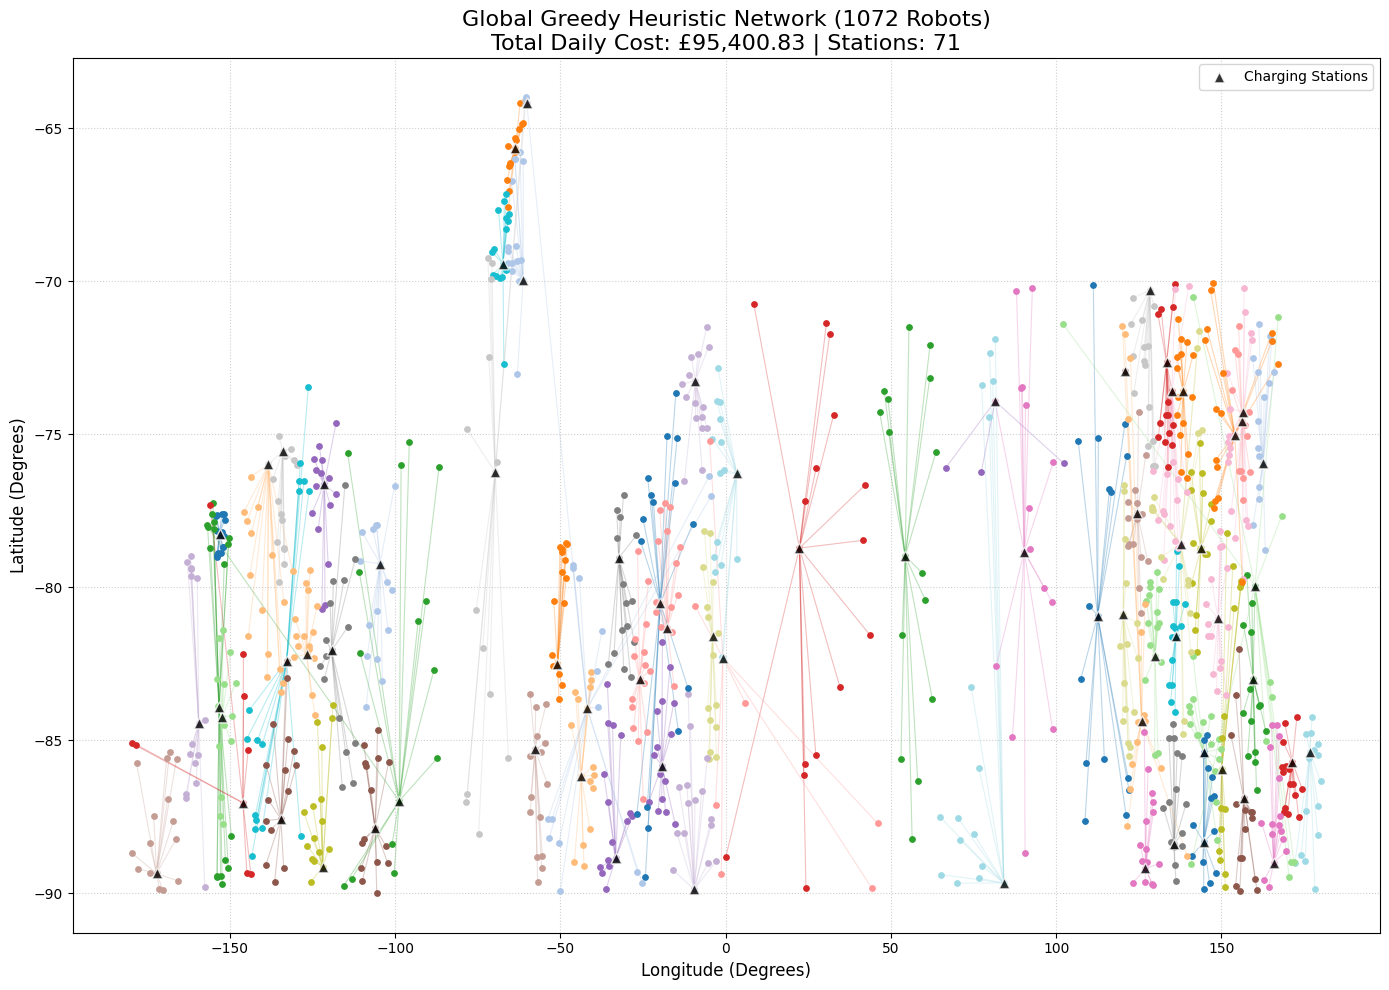


=== Starting LOCAL SEARCH HEURISTIC (Phase 1 -> 2 -> 3) ===

[Initial State] Greedy service cost (excluding penalties): £95400.83 | Stations: 71
[Phase 1 Finished] Executed 121 transfers. Service Cost: £95116.99 | Stations: 71 | Time: 1.70s
[Phase 2 Finished] Executed 0 merges. Service Cost: £95116.99 | Stations: 71 | Time: 0.00s
[Phase 3 Finished] Executed 8 fine-tuning adjustments. Final Service Cost: £95086.02 | Time: 0.01s

================ Final Optimization Results ================
Total Cost before Local Search (Greedy): £95400.83
Total Cost after Local Search (LS):      £95086.02
Total Cost Savings Achieved:             £314.81



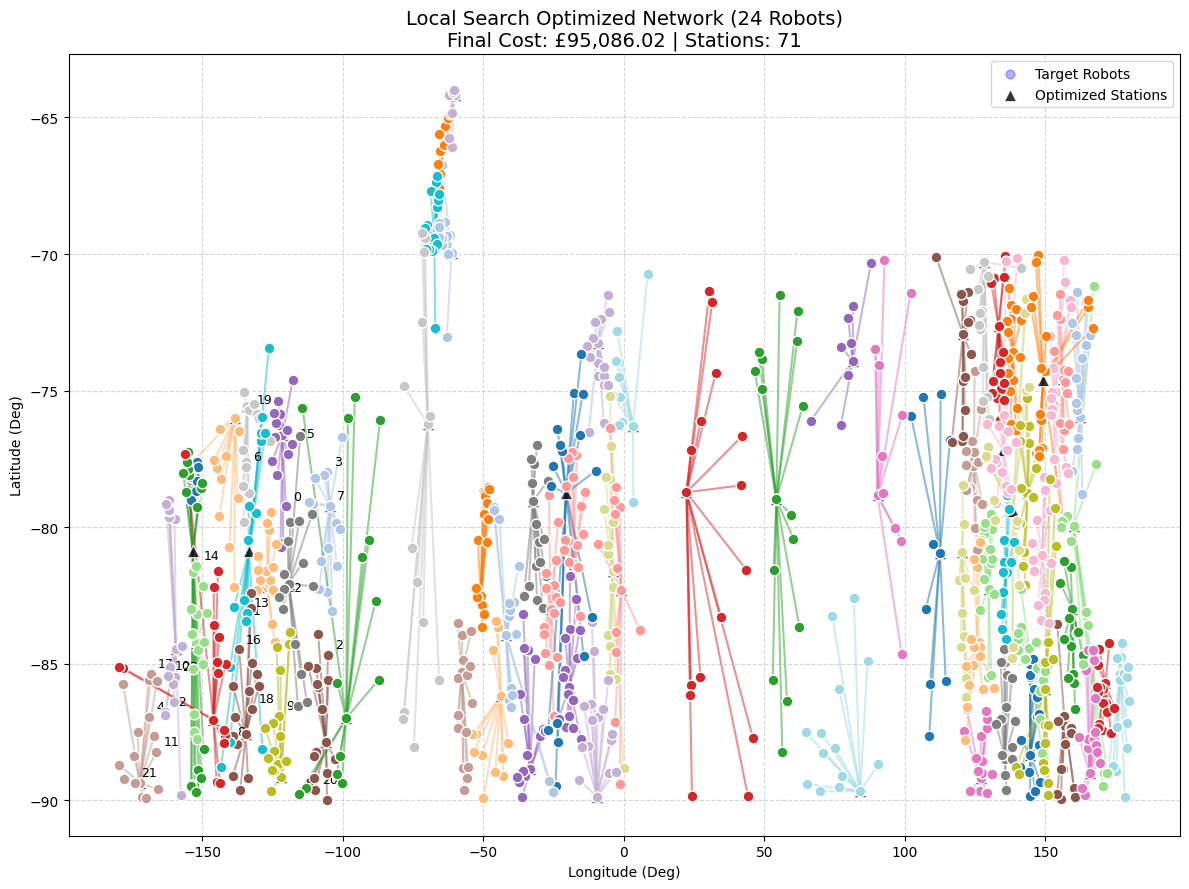

In [3]:
# full model 1072
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import time

# =========================================================
# 1. Data Loading and Preprocessing
# =========================================================
df_loc = pd.read_csv('robot_locations.csv')
df_range = pd.read_csv('range.csv')

# Extract coordinates and ranges
coords = df_loc[['longitude', 'latitude']].values
ranges = df_range['range'].values
N = len(coords)

# =========================================================
# 2. Distance Matrix Calculation (Using direct Euclidean distance)
# =========================================================
diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

# =========================================================
# 3. Cost Parameters
# =========================================================
C_b = 5000                
C_m = 500                 
C_b_daily = C_b / 365.0   # Daily station construction cost (approx £13.70)
C_m_daily = C_m / 365.0   # Daily maintenance cost (approx £1.37)
C_c = 0.42                
C_h = 1000                
MAX_ROBOTS = 16           
R_MAX = 175 * 1.60934     # Max range aligned with 1(a)

# =========================================================
# 4. Greedy Heuristic (Full set of 1072 robots)
# =========================================================
unassigned = set(range(N))
candidates = set(range(N))

stations_built = []      
total_cost = 0

print(f"===================================================")
print(f"Starting Global Test: Finding optimal station placement for all {N} robots...")
print(f"Cost Logic: Base charging (R_max - r_i) included, build/maint costs amortized daily")
print(f"===================================================")

start_time = time.time()
iteration = 0

while unassigned:
    best_savings = 0
    best_candidate = None
    best_subset = []
    best_cost_serve = 0
    
    for j in candidates:
        reachable = []
        for i in unassigned:
            if dist_matrix[i, j] <= ranges[i]:
                reachable.append(i)
                
        if not reachable: continue
            
        # Prioritize closest robots first
        reachable.sort(key=lambda i: dist_matrix[i, j])
        subset = reachable[:MAX_ROBOTS]
        n_served = len(subset)
        
        # Comparison: Penalty cost vs. Service cost
        cost_penalty = n_served * C_h
        chargers_needed = math.ceil(n_served / 2)
        
        # ★ Core logic: (R_MAX - self_range + flight_distance) * 0.42
        cost_flying = sum((R_MAX - ranges[i] + dist_matrix[i, j]) * C_c for i in subset)
        cost_serve = C_b_daily + (chargers_needed * C_m_daily) + cost_flying
        
        savings = cost_penalty - cost_serve
        
        if savings > best_savings:
            best_savings = savings
            best_candidate = j
            best_subset = subset
            best_cost_serve = cost_serve
            
    if best_savings > 0:
        iteration += 1
        stations_built.append((best_candidate, best_subset))
        total_cost += best_cost_serve
        
        # Resource update
        candidates.remove(best_candidate)
        for robot in best_subset: unassigned.remove(robot)
        
        # Print progress every 50 stations built
        if iteration % 50 == 0:
            print(f"Progress Report: {iteration} stations built, {len(unassigned)} robots remaining...")
    else:
        break

unassigned_cost = len(unassigned) * C_h
total_cost += unassigned_cost

end_time = time.time()

print(f"\n================ Global Test Completed ================")
print(f"Total Stations Built: {len(stations_built)}")
print(f"Robots Successfully Served: {N - len(unassigned)}")
print(f"Unserved Robots (Penalty Incurred): {len(unassigned)}")
print(f"Total Network Cost (Objective Value): £{total_cost:,.2f}")
print(f"Algorithm Execution Time: {end_time - start_time:.4f} seconds")
print(f"======================================================")

# =========================================================
# 5. Global Visualization
# =========================================================
fig, ax = plt.subplots(figsize=(14, 10))

# 1. Plot all unserved robots (Red 'x')
unassigned_list = list(unassigned)
if unassigned_list:
    ax.scatter(coords[unassigned_list, 0], coords[unassigned_list, 1], 
               c='red', marker='x', s=40, linewidth=1.5, label='Unassigned (Penalty)', zorder=3)

station_coords_x, station_coords_y = [], []
cmap = plt.get_cmap('tab20') 

# 2. Plot stations, connection lines, and served robots
for idx, (stat_id, robots) in enumerate(stations_built):
    color = cmap(idx % 20)
    sx, sy = coords[stat_id]
    station_coords_x.append(sx)
    station_coords_y.append(sy)
    
    for r_id in robots:
        rx, ry = coords[r_id]
        ax.plot([rx, sx], [ry, sy], c=color, alpha=0.3, linewidth=0.8, zorder=1)
        ax.scatter(rx, ry, c=[color], s=15, zorder=2)

# 3. Plot station icons (Black triangles on top)
if station_coords_x:
    ax.scatter(station_coords_x, station_coords_y, c='black', marker='^', s=60, alpha=0.8, edgecolors='white', zorder=4, label='Charging Stations')

ax.set_title(f'Global Greedy Heuristic Network (1072 Robots)\nTotal Daily Cost: £{total_cost:,.2f} | Stations: {len(stations_built)}', fontsize=16)
ax.set_xlabel('Longitude (Degrees)', fontsize=12)
ax.set_ylabel('Latitude (Degrees)', fontsize=12)

# Legend optimization
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='best', fontsize=10)

ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()









# =========================================================
# 6. LOCAL SEARCH HEURISTIC (Phase 1 -> 2 -> 3)
# =========================================================
import copy

print("\n=======================================================")
print("=== Starting LOCAL SEARCH HEURISTIC (Phase 1 -> 2 -> 3) ===")
print("=======================================================\n")

# Helper Function 1: Calculate Euclidean distance between two points
def calc_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# Helper Function 2: Calculate actual total cost for a station (Aligned with Greedy logic)
def calc_station_cost(station_coords, robots_list):
    if not robots_list:
        return 0 # Empty stations incur no cost
    chargers = math.ceil(len(robots_list) / 2)
    c_fly = sum((R_MAX - ranges[r] + calc_dist(coords[r], station_coords)) * C_c for r in robots_list)
    return C_b_daily + chargers * C_m_daily + c_fly

# =========================================================
# Initialize Local Search State
# =========================================================
active_stations = {}
stat_counter = 0
for stat_id, r_list in stations_built:
    active_stations[stat_counter] = {
        'coords': (coords[stat_id][0], coords[stat_id][1]),
        'robots': list(r_list)
    }
    stat_counter += 1

current_ls_cost = sum(calc_station_cost(s['coords'], s['robots']) for s in active_stations.values())
print(f"[Initial State] Greedy service cost (excluding penalties): £{current_ls_cost:.2f} | Stations: {len(active_stations)}")

# =========================================================
# Phase 1: Reassign & Drop (1-Shift)
# =========================================================
start_p1 = time.time()
improvement = True
iter_p1 = 0

while improvement:
    improvement = False
    stat_ids = list(active_stations.keys())
    
    for s_old_id in stat_ids:
        if s_old_id not in active_stations: continue
        
        robots_in_old = list(active_stations[s_old_id]['robots'])
        for robot in robots_in_old:
            best_move_savings = 0.001
            best_s_new_id = None
            
            for s_new_id in stat_ids:
                if s_new_id == s_old_id or s_new_id not in active_stations: continue
                if len(active_stations[s_new_id]['robots']) >= MAX_ROBOTS: continue
                
                new_coords = active_stations[s_new_id]['coords']
                if calc_dist(coords[robot], new_coords) > ranges[robot]: continue
                
                old_cost_A = calc_station_cost(active_stations[s_old_id]['coords'], active_stations[s_old_id]['robots'])
                old_cost_B = calc_station_cost(active_stations[s_new_id]['coords'], active_stations[s_new_id]['robots'])
                
                temp_old_robots = [r for r in active_stations[s_old_id]['robots'] if r != robot]
                temp_new_robots = active_stations[s_new_id]['robots'] + [robot]
                
                new_cost_A = calc_station_cost(active_stations[s_old_id]['coords'], temp_old_robots)
                new_cost_B = calc_station_cost(active_stations[s_new_id]['coords'], temp_new_robots)
                
                savings = (old_cost_A + old_cost_B) - (new_cost_A + new_cost_B)
                
                if savings > best_move_savings:
                    best_move_savings = savings
                    best_s_new_id = s_new_id
            
            if best_s_new_id is not None:
                active_stations[s_old_id]['robots'].remove(robot)
                active_stations[best_s_new_id]['robots'].append(robot)
                current_ls_cost -= best_move_savings
                improvement = True
                iter_p1 += 1
                
        if len(active_stations[s_old_id]['robots']) == 0:
            del active_stations[s_old_id]

print(
    f"[Phase 1 Finished] Executed {iter_p1} transfers. "
    f"Service Cost: £{current_ls_cost:.2f} | "
    f"Stations: {len(active_stations)} | "
    f"Time: {time.time()-start_p1:.2f}s"
)

# =========================================================
# Phase 2: Merge & Shift (k-to-1 continuous drift)
# =========================================================
start_p2 = time.time()
improvement = True
iter_p2 = 0
K_MAX = 3

while improvement:
    improvement = False
    stat_ids = list(active_stations.keys())
    
    for i in range(len(stat_ids)):
        if stat_ids[i] not in active_stations: continue
        stat_A_id = stat_ids[i]
        
        neighbors = []
        for j in range(len(stat_ids)):
            if i != j and stat_ids[j] in active_stations:
                d = calc_dist(active_stations[stat_A_id]['coords'], active_stations[stat_ids[j]]['coords'])
                neighbors.append((d, stat_ids[j]))
        
        neighbors.sort()
        closest_neighbors = [nid for d, nid in neighbors[:K_MAX-1]]
        
        merge_candidates = []
        for k in range(2, K_MAX + 1):
            if len(closest_neighbors) >= k - 1:
                merge_candidates.append([stat_A_id] + closest_neighbors[:k-1])
                
        best_merge_savings = 0.001
        best_merge_plan = None
        best_new_coords = None
        
        for cand_group in merge_candidates:
            combined_robots = []
            for s_id in cand_group:
                combined_robots.extend(active_stations[s_id]['robots'])
                
            if len(combined_robots) > MAX_ROBOTS: continue
            
            robot_coords = coords[combined_robots]
            new_coords = (np.mean(robot_coords[:, 0]), np.mean(robot_coords[:, 1]))
            
            if any(calc_dist(coords[r], new_coords) > ranges[r] for r in combined_robots):
                continue
                
            old_cost = sum(calc_station_cost(active_stations[s]['coords'], active_stations[s]['robots']) for s in cand_group)
            new_cost = calc_station_cost(new_coords, combined_robots)
            
            savings = old_cost - new_cost
            if savings > best_merge_savings:
                best_merge_savings = savings
                best_merge_plan = (cand_group, combined_robots)
                best_new_coords = new_coords
                
        if best_merge_plan is not None:
            cand_group, combined_robots = best_merge_plan
            for s_id in cand_group:
                del active_stations[s_id]
            
            new_stat_id = stat_counter
            stat_counter += 1
            active_stations[new_stat_id] = {'coords': best_new_coords, 'robots': combined_robots}
            
            current_ls_cost -= best_merge_savings
            improvement = True
            iter_p2 += 1
            break

print(
    f"[Phase 2 Finished] Executed {iter_p2} merges. "
    f"Service Cost: £{current_ls_cost:.2f} | "
    f"Stations: {len(active_stations)} | "
    f"Time: {time.time()-start_p2:.2f}s"
)

# =========================================================
# Phase 3: Weiszfeld Shift (Geometric Median Fine-tuning)
# =========================================================
start_p3 = time.time()
iter_p3 = 0

for s_id, stat_data in active_stations.items():
    robots = stat_data['robots']
    if len(robots) <= 1: continue 
        
    current_coords = np.array(stat_data['coords'])
    robot_coords = coords[robots]
    
    best_cost = calc_station_cost(current_coords, robots)
    best_coords = current_coords
    test_coords = current_coords.copy()
    
    for _ in range(30):
        diff = robot_coords - test_coords
        dists = np.sqrt(np.sum(diff**2, axis=1))
        dists[dists < 1e-9] = 1e-9 
        
        weights = 1.0 / dists
        new_x = np.sum(weights * robot_coords[:, 0]) / np.sum(weights)
        new_y = np.sum(weights * robot_coords[:, 1]) / np.sum(weights)
        new_coords = np.array([new_x, new_y])
        
        if np.sqrt(np.sum((new_coords - test_coords)**2)) < 1e-6:
            break
            
        if any(calc_dist(coords[r], new_coords) > ranges[r] for r in robots):
            break
            
        new_cost = calc_station_cost(new_coords, robots)
        if new_cost < best_cost:
            best_cost = new_cost
            best_coords = new_coords
            test_coords = new_coords
        else:
            break
            
    savings = calc_station_cost(stat_data['coords'], robots) - best_cost
    if savings > 1e-4:
        active_stations[s_id]['coords'] = (best_coords[0], best_coords[1])
        current_ls_cost -= savings
        iter_p3 += 1

print(
    f"[Phase 3 Finished] Executed {iter_p3} fine-tuning adjustments. "
    f"Final Service Cost: £{current_ls_cost:.2f} | "
    f"Time: {time.time()-start_p3:.2f}s"
)

# =========================================================
# Summary and Visualization
# =========================================================
final_total_cost = current_ls_cost + unassigned_cost
print(f"\n================ Final Optimization Results ================")
print(f"Total Cost before Local Search (Greedy): £{total_cost:.2f}")
print(f"Total Cost after Local Search (LS):      £{final_total_cost:.2f}")
print(f"Total Cost Savings Achieved:             £{total_cost - final_total_cost:.2f}")
print("============================================================\n")

fig, ax = plt.subplots(figsize=(12, 9))

# ID Labels
for i in range(SUBSET_SIZE):
    ax.annotate(str(i), (coords[i, 0], coords[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.scatter(coords[:SUBSET_SIZE, 0], coords[:SUBSET_SIZE, 1], c='blue', s=40, alpha=0.3, label='Target Robots', zorder=2)

unassigned_list = list(unassigned)
if unassigned_list:
    ax.scatter(coords[unassigned_list, 0], coords[unassigned_list, 1], 
               c='red', marker='x', s=100, linewidth=2, label='Unassigned (Penalty)', zorder=3)

ls_station_x, ls_station_y = [], []
cmap = plt.get_cmap('tab20')

for idx, stat_data in enumerate(active_stations.values()):
    color = cmap(idx % 20)
    sx, sy = stat_data['coords']
    ls_station_x.append(sx)
    ls_station_y.append(sy)
    
    for r_id in stat_data['robots']:
        rx, ry = coords[r_id]
        ax.plot([rx, sx], [ry, sy], c=color, alpha=0.5, linewidth=1.5, zorder=1)
        ax.scatter(rx, ry, c=[color], s=60, edgecolors='white', zorder=5)

if ls_station_x:
    ax.scatter(ls_station_x, ls_station_y, c='black', marker='^', s=80, alpha=0.8, edgecolors='white', zorder=4, label='Optimized Stations')

ax.set_title(f'Local Search Optimized Network (24 Robots)\nFinal Cost: £{final_total_cost:,.2f} | Stations: {len(active_stations)}', fontsize=14)
ax.set_xlabel('Longitude (Deg)')
ax.set_ylabel('Latitude (Deg)')
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()